<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/yolo_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

### simplified model

In [3]:
class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YOLOv1, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        # Simple CNN backbone
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 192, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(192, 256, 3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(512, 1024, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (B * 5 + C))
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x.reshape(-1, self.S, self.S, self.B * 5 + self.C)

### loss function


In [4]:
class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YOLOv1, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 192, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(192, 256, 3, padding=1),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(512, 1024, 3, padding=1),
            nn.LeakyReLU(0.1),
        )

        # 🔥 THIS FIXES EVERYTHING
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (B * 5 + C))
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.adaptive_pool(x)   # 🔥 KEY LINE
        x = self.fc(x)
        return x.reshape(-1, self.S, self.S, self.B * 5 + self.C)

# fake data!

In [5]:
class DummyDataset(torch.utils.data.Dataset):
    def __init__(self, size=100):
        self.size = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        img = torch.randn(3, 448, 448)
        label = torch.zeros(7, 7, 30)

        # random object
        i, j = torch.randint(0, 7, (2,))
        label[i, j, 4] = 1  # confidence
        label[i, j, 0:4] = torch.rand(4)

        return img, label

### IOU function

In [9]:
def intersection_over_union(boxes_preds, boxes_labels):
    """
    boxes_preds: (N, 4)
    boxes_labels: (N, 4)
    format: (x, y, w, h)
    """

    box1_x1 = boxes_preds[..., 0] - boxes_preds[..., 2] / 2
    box1_y1 = boxes_preds[..., 1] - boxes_preds[..., 3] / 2
    box1_x2 = boxes_preds[..., 0] + boxes_preds[..., 2] / 2
    box1_y2 = boxes_preds[..., 1] + boxes_preds[..., 3] / 2

    box2_x1 = boxes_labels[..., 0] - boxes_labels[..., 2] / 2
    box2_y1 = boxes_labels[..., 1] - boxes_labels[..., 3] / 2
    box2_x2 = boxes_labels[..., 0] + boxes_labels[..., 2] / 2
    box2_y2 = boxes_labels[..., 1] + boxes_labels[..., 3] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

In [7]:
class YOLOLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YOLOLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")

        self.S = S
        self.B = B
        self.C = C

        self.lambda_coord = 5
        self.lambda_noobj = 0.5

    def forward(self, predictions, target):
        # reshape
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # split predictions
        pred_boxes1 = predictions[..., 21:25]
        pred_boxes2 = predictions[..., 26:30]

        # ground truth
        target_box = target[..., 21:25]
        exists_box = target[..., 20].unsqueeze(3)  # object mask

        # IOU for both boxes
        iou1 = intersection_over_union(pred_boxes1, target_box)
        iou2 = intersection_over_union(pred_boxes2, target_box)

        ious = torch.stack([iou1, iou2], dim=0)
        iou_maxes, best_box = torch.max(ious, dim=0)

        best_box = best_box.unsqueeze(-1)

        # select best box
        box_predictions = exists_box * (
            best_box * pred_boxes2 + (1 - best_box) * pred_boxes1
        )

        box_targets = exists_box * target_box

        # 📍 BOX LOSS (sqrt for w,h)
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        # 🎯 OBJECT LOSS
        pred_box_conf = (
            best_box * predictions[..., 25:26]
            + (1 - best_box) * predictions[..., 20:21]
        )

        object_loss = self.mse(
            torch.flatten(exists_box * pred_box_conf),
            torch.flatten(exists_box * target[..., 20:21]),
        )

        # 🚫 NO OBJECT LOSS
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 20:21]),
            torch.flatten((1 - exists_box) * target[..., 20:21]),
        )

        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 25:26]),
            torch.flatten((1 - exists_box) * target[..., 20:21]),
        )

        # 🏷️ CLASS LOSS
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :20], end_dim=-2),
            torch.flatten(exists_box * target[..., :20], end_dim=-2),
        )

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLOv1().to(device)
loss_fn = YOLOLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

dataset = DummyDataset()
loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

EPOCHS = 5

for epoch in range(EPOCHS):
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 7.230373002588749
Epoch 2, Loss: 0.07008714316179976
Epoch 3, Loss: 0.011066939696320333
Epoch 4, Loss: 0.002745570585830137
Epoch 5, Loss: 0.0005772083377451054


### real data


In [11]:
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
!tar -xvf VOCtrainval_11-May-2012.tar

Streaming output truncated to the last 5000 lines.
VOCdevkit/VOC2012/SegmentationClass/2008_001874.png
VOCdevkit/VOC2012/SegmentationClass/2008_001876.png
VOCdevkit/VOC2012/SegmentationClass/2008_001882.png
VOCdevkit/VOC2012/SegmentationClass/2008_001885.png
VOCdevkit/VOC2012/SegmentationClass/2008_001895.png
VOCdevkit/VOC2012/SegmentationClass/2008_001896.png
VOCdevkit/VOC2012/SegmentationClass/2008_001926.png
VOCdevkit/VOC2012/SegmentationClass/2008_001966.png
VOCdevkit/VOC2012/SegmentationClass/2008_001971.png
VOCdevkit/VOC2012/SegmentationClass/2008_001992.png
VOCdevkit/VOC2012/SegmentationClass/2008_001997.png
VOCdevkit/VOC2012/SegmentationClass/2008_002032.png
VOCdevkit/VOC2012/SegmentationClass/2008_002043.png
VOCdevkit/VOC2012/SegmentationClass/2008_002064.png
VOCdevkit/VOC2012/SegmentationClass/2008_002066.png
VOCdevkit/VOC2012/SegmentationClass/2008_002067.png
VOCdevkit/VOC2012/SegmentationClass/2008_002073.png
VOCdevkit/VOC2012/SegmentationClass/2008_002079.png
VOCdevkit/VOC

In [12]:
VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]

class_to_idx = {cls: i for i, cls in enumerate(VOC_CLASSES)}

## visualize dataset

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [14]:
def visualize_sample(dataset, idx):
    img, target = dataset[idx]

    img = img.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    S = 7

    for i in range(S):
        for j in range(S):
            if target[i, j, 20] == 1:  # object exists

                x_cell, y_cell, w, h = target[i, j, 21:25]

                # convert back to image coordinates
                x = (j + x_cell) / S
                y = (i + y_cell) / S

                x *= 448
                y *= 448
                w *= 448
                h *= 448

                rect = patches.Rectangle(
                    (x - w/2, y - h/2),
                    w,
                    h,
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none'
                )

                ax.add_patch(rect)

    plt.show()

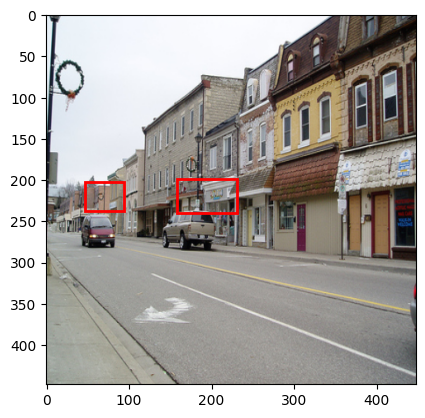

In [21]:
visualize_sample(dataset, idx=4)

In [16]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

In [17]:
class VOCDataset(torch.utils.data.Dataset):
    def __init__(self, root, image_set="train", transform=None, S=7, B=2, C=20):
        self.root = root
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C

        image_set_file = os.path.join(root, "ImageSets/Main", f"{image_set}.txt")
        with open(image_set_file) as f:
            self.image_ids = f.read().strip().split()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        img_path = os.path.join(self.root, "JPEGImages", img_id + ".jpg")
        label_path = os.path.join(self.root, "Annotations", img_id + ".xml")

        image = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []

        tree = ET.parse(label_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            cls = obj.find("name").text
            if cls not in class_to_idx:
                continue

            label = class_to_idx[cls]

            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        boxes = torch.tensor(boxes)
        labels = torch.tensor(labels)

        if self.transform:
            image = self.transform(image)

        target = self.encode(boxes, labels, image.shape[1], image.shape[2])

        return image, target

    # 🔥 MOVE THIS INSIDE CLASS
    def encode(self, boxes, labels, img_w, img_h):
        target = torch.zeros((self.S, self.S, self.C + self.B * 5))

        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box

            x = (xmin + xmax) / 2 / img_w
            y = (ymin + ymax) / 2 / img_h
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h

            i = int(self.S * y)
            j = int(self.S * x)

            i = min(i, self.S - 1)
            j = min(j, self.S - 1)

            x_cell = self.S * x - j
            y_cell = self.S * y - i

            if target[i, j, 20] == 0:
                target[i, j, 20] = 1
                target[i, j, 21:25] = torch.tensor([x_cell, y_cell, w, h])
                target[i, j, label] = 1

        return target

In [18]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])

In [19]:
dataset = VOCDataset(
    root="/content/VOCdevkit/VOC2012",
    image_set="train",
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [20]:
for epoch in range(10):
    total_loss = 0

    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        preds = model(imgs)
        loss = loss_fn(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 43951.944120407104
Epoch 2, Loss: 41805.17023277283
Epoch 3, Loss: 41138.49801445007
Epoch 4, Loss: 40724.12730026245
Epoch 5, Loss: 39745.991771698
Epoch 6, Loss: 38409.11661529541
Epoch 7, Loss: 36439.576864242554
Epoch 8, Loss: 33859.65340042114
Epoch 9, Loss: 30462.480337142944
Epoch 10, Loss: 26952.08247947693


In [38]:
def decode_predictions(preds, S=7, C=20):
    boxes = []

    preds = preds.squeeze(0)  # remove batch

    for i in range(S):
        for j in range(S):

            cell = preds[i, j]

            class_probs = cell[:C]
            class_idx = torch.argmax(class_probs)
            class_score = class_probs[class_idx]

            conf1 = cell[20]
            box1 = cell[21:25]

            conf2 = cell[25]
            box2 = cell[26:30]

            # choose better box
            if conf1 > conf2:
                conf = conf1
                box = box1
            else:
                conf = conf2
                box = box2

            score = conf * class_score

            if score > 0.1:  # threshold
                x, y, w, h = box

                x = (j + x) / S
                y = (i + y) / S

                boxes.append([
                    x.item(),
                    y.item(),
                    w.item(),
                    h.item(),
                    score.item(),
                    class_idx.item()
                ])

    return boxes

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [40]:
def plot_predictions(image, boxes):
    img = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    for box in boxes:
        x, y, w, h, score, cls = box

        x *= 448
        y *= 448
        w *= 448
        h *= 448

        rect = patches.Rectangle(
            (x - w/2, y - h/2),
            w,
            h,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )

        ax.add_patch(rect)

    plt.show()

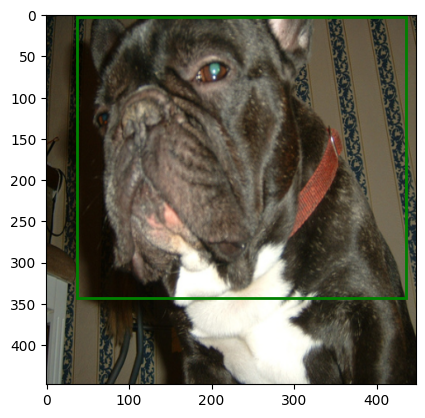

In [41]:
model.eval()

img, _ = dataset[10]  # pick any image
img = img.to(device).unsqueeze(0)

with torch.no_grad():
    preds = model(img)

boxes = decode_predictions(preds.cpu())

plot_predictions(img[0].cpu(), boxes)

In [42]:
def iou(box1, box2):
    x1 = max(box1[0] - box1[2]/2, box2[0] - box2[2]/2)
    y1 = max(box1[1] - box1[3]/2, box2[1] - box2[3]/2)
    x2 = min(box1[0] + box1[2]/2, box2[0] + box2[2]/2)
    y2 = min(box1[1] + box1[3]/2, box2[1] + box2[3]/2)

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]

    return inter / (area1 + area2 - inter + 1e-6)

In [43]:
def non_max_suppression(boxes, iou_threshold=0.5):
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)

    final_boxes = []

    while boxes:
        chosen = boxes.pop(0)
        final_boxes.append(chosen)

        boxes = [
            box for box in boxes
            if iou(chosen, box) < iou_threshold
        ]

    return final_boxes

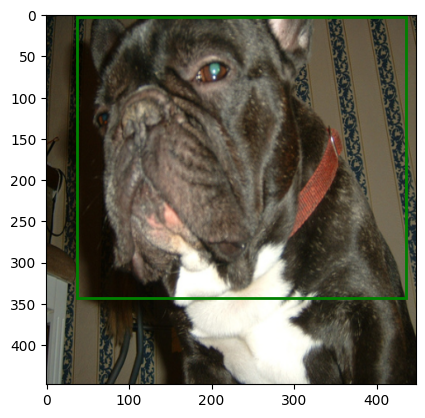

In [44]:
boxes = decode_predictions(preds.cpu())
boxes = non_max_suppression(boxes)

plot_predictions(img[0].cpu(), boxes)